# Load library

In [88]:
import os
import pandas as pd
import optuna
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
import joblib
import numpy as np
import shap
import warnings
from sklearn.exceptions import DataConversionWarning

from Functions import BDG2, preprocess, main

csvs = [file for file in os.listdir('./Data/LondonHydro/') if file.endswith('.csv')]
df_name = 'LondonHydro'
more_info = csvs[0]
df = pd.read_csv(f'./Data/LondonHydro/{csvs[0]}')

numerical_columns = ['energy_consumption', 'temperature', 'humidity', 'wind_speed']
categorical_columns = None
binary_columns = None
datetime_column = 'timestamp'
target_column = 'energy_consumption'

df[target_column] = np.exp(df[target_column])

df = preprocess.pre_process(df, numerical_columns, categorical_columns, binary_columns, datetime_column, target_column)

df = preprocess.get_datetime_features(df, datetime_column, cos_sin = False)

feature_names = ["Hour", "DayOfWeek", "DayOfMonth", "Month", "DayOfYear", "IsWeekend", "temperature", "humidity", "wind_speed", "energy_consumption"]
df = df[feature_names]

#scale type = both, features, outcome
X_train, y_train, X_val, y_val, X_test, y_test, X, y, df_scaled = preprocess.load_and_preprocess_data_with_sequences(df, target='energy_consumption', scaled=True, scale_type='features', val_ratio=0.1, test_ratio=0.1, input_seq_length=48, output_seq_length=24)

cleaned_df = df_scaled

data = (X_train, y_train, X_val, y_val, X_test, y_test)

# Print shapes to verify
print("\nShapes:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

df_scaled.head()


Shapes:
X_train: (20391, 48, 10)
y_train: (20391, 24, 1)
X_val: (2548, 48, 10)
y_val: (2548, 24, 1)
X_test: (2548, 48, 10)
y_test: (2548, 24, 1)


,Hour,DayOfWeek,DayOfMonth,Month,DayOfYear,IsWeekend,temperature,humidity,wind_speed,energy_consumption
timestamp,,,,,,,,,,
2002-01-01 01:00:00,0.043478,0.166667,0.0,0.0,0.0,0.0,0.312925,0.760000,0.270270,3.632787
2002-01-01 02:00:00,0.086957,0.166667,0.0,0.0,0.0,0.0,0.302721,0.786667,0.270270,3.560853
2002-01-01 03:00:00,0.130435,0.166667,0.0,0.0,0.0,0.0,0.287415,0.826667,0.256757,3.706174
2002-01-01 04:00:00,0.173913,0.166667,0.0,0.0,0.0,0.0,0.278912,0.853333,0.175676,3.490343
2002-01-01 05:00:00,0.217391,0.166667,0.0,0.0,0.0,0.0,0.277211,0.853333,0.148649,3.669297


In [108]:
from tensorflow.keras import layers, models
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import time
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, Dropout, Add, Dense, LayerNormalization, Reshape
from tensorflow.keras.models import Model

import pandas as pd
from Functions import BDG2, preprocess, my

def calculate_mape(y_true, y_pred):
    return 100 * np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 1e-8, None)))

def calculate_smape(y_true, y_pred):
    denominator = np.abs(y_true) + np.abs(y_pred)
    return 100 * np.mean(2.0 * np.abs(y_true - y_pred) / np.clip(denominator, 1e-8, None))


def calculate_mape(y_true, y_pred):
    return 100 * np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 1e-8, None)))

def calculate_smape(y_true, y_pred):
    denominator = np.abs(y_true) + np.abs(y_pred)
    return 100 * np.mean(2.0 * np.abs(y_true - y_pred) / np.clip(denominator, 1e-8, None))


# https://github.com/buds-lab/building-data-genome-project-2/tree/master/data/meters/cleaned
# Unique Primary Uses: ['services', 'health', 'education', 'lodging', 'industrial', 'unknown', 'office', 'retail', 'food', 'other', 'religion', 'utility', 'public', 'science', 'warehouse', 'parking', 'assembly']

df = pd.read_csv('./Data/building-data-genome-project-2/electricity_cleaned.txt')

target_column = 'energy_consumption'

# df_name = "industrial" #PrimaryUses Manufacturing corresponds to 'industrial'. option_number=1
# df_name = "health" #PrimaryUses Medical Clinic corresponds to 'health'. option_number=1
df_name = "retail" #PrimaryUses Retail Store corresponds to 'retail'. option_number=3
# df_name = "office" #PrimaryUses Office corresponds to 'office'. option_number=1
cleaned_df, more_info = BDG2.get_column_by_criteria(df, primary_use=df_name, option_number=2)

#scale type = both, features, outcome
X_train, y_train, X_val, y_val, X_test, y_test, X, y, df_scaled = preprocess.load_and_preprocess_data_with_sequences(cleaned_df, target=target_column, scaled=True, scale_type='features', val_ratio=0.1, test_ratio=0.1, input_seq_length=48, output_seq_length=1)

data = (X_train, y_train, X_val, y_val, X_test, y_test)

# Print shapes to verify
print("\nShapes:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

df_scaled.head()

Number of missing values before filling: 2907
Number of missing values after filling: 0
Primary Use: 'retail'
Building Name: 'Romeo'
SiteID: 'Panther'
Filling missing values in column 'energy_consumption' with 0.00% missing values.
Filling missing values in column 'Hour' with 0.00% missing values.
Filling missing values in column 'DayOfWeek' with 0.00% missing values.
Filling missing values in column 'DayOfMonth' with 0.00% missing values.
Filling missing values in column 'Month' with 0.00% missing values.
Filling missing values in column 'DayOfYear' with 0.00% missing values.
Filling missing values in column 'IsWeekend' with 0.00% missing values.
Filling missing values in column 'airTemperature' with 0.00% missing values.
Filling missing values in column 'dewTemperature' with 0.00% missing values.
Filling missing values in column 'seaLvlPressure' with 0.00% missing values.
Filling missing values in column 'windSpeed' with 0.00% missing values.

Shapes:
X_train: (13615, 48, 11)
y_train

,energy_consumption,Hour,DayOfWeek,DayOfMonth,Month,DayOfYear,IsWeekend,airTemperature,dewTemperature,seaLvlPressure,windSpeed
timestamp,,,,,,,,,,,
2016-01-20 23:00:00,0.073,1.000000,0.333333,0.633333,0.0,0.052055,0.0,0.191860,0.447721,0.726862,0.097403
2016-01-21 00:00:00,0.073,0.000000,0.500000,0.666667,0.0,0.054795,0.0,0.209302,0.463807,0.720090,0.000000
2016-01-21 01:00:00,0.073,0.043478,0.500000,0.666667,0.0,0.054795,0.0,0.209302,0.463807,0.713318,0.000000
2016-01-21 02:00:00,0.073,0.086957,0.500000,0.666667,0.0,0.054795,0.0,0.191860,0.463807,0.706546,0.000000
2016-01-21 03:00:00,0.073,0.130435,0.500000,0.666667,0.0,0.054795,0.0,0.159884,0.434316,0.697517,0.000000


Epoch 1/10
426/426 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 155230.0312 - mae: 341.0889 - val_loss: 2468.1250 - val_mae: 39.3683
Epoch 2/10
426/426 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 13266.2861 - mae: 63.1180 - val_loss: 5596.5352 - val_mae: 65.5593
Epoch 3/10
426/426 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 11730.6279 - mae: 63.3017 - val_loss: 5819.8120 - val_mae: 66.7736
Epoch 4/10
426/426 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 12075.4014 - mae: 64.1323 - val_loss: 6197.3652 - val_mae: 68.7990
Epoch 5/10
426/426 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 11565.4795 - mae: 63.4415 - val_loss: 6182.4951 - val_mae: 68.7153
Epoch 6/10
426/426 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 12401.1729 - mae: 65.3154 - val_loss: 5866.6514 - val_mae: 67.0156
Epoch 7/10
426/426 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 11861.2842 - mae: 63.6898 - val_loss: 6034.0806 - val_mae: 67.9167
Epoch 8/10
426/426 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 11889.5410 - mae: 64.3143 - val_loss: 5373.2485 -

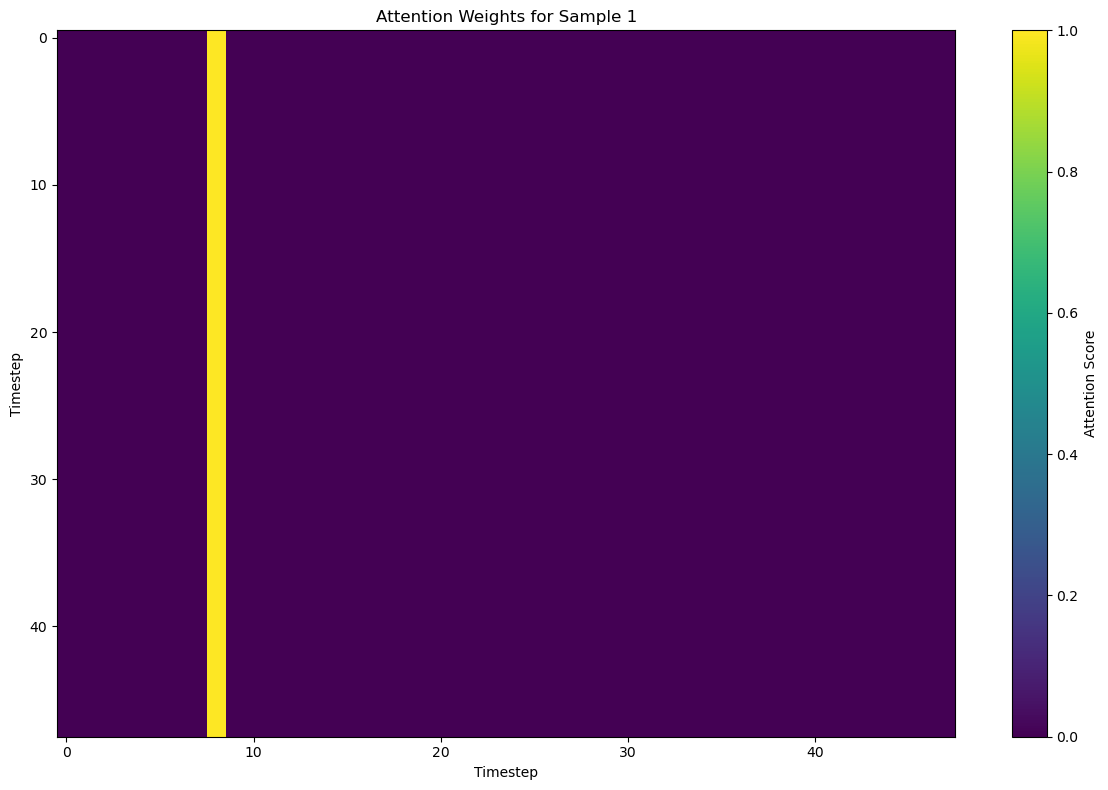

Sample 2 attention weights shape: (48, 48)


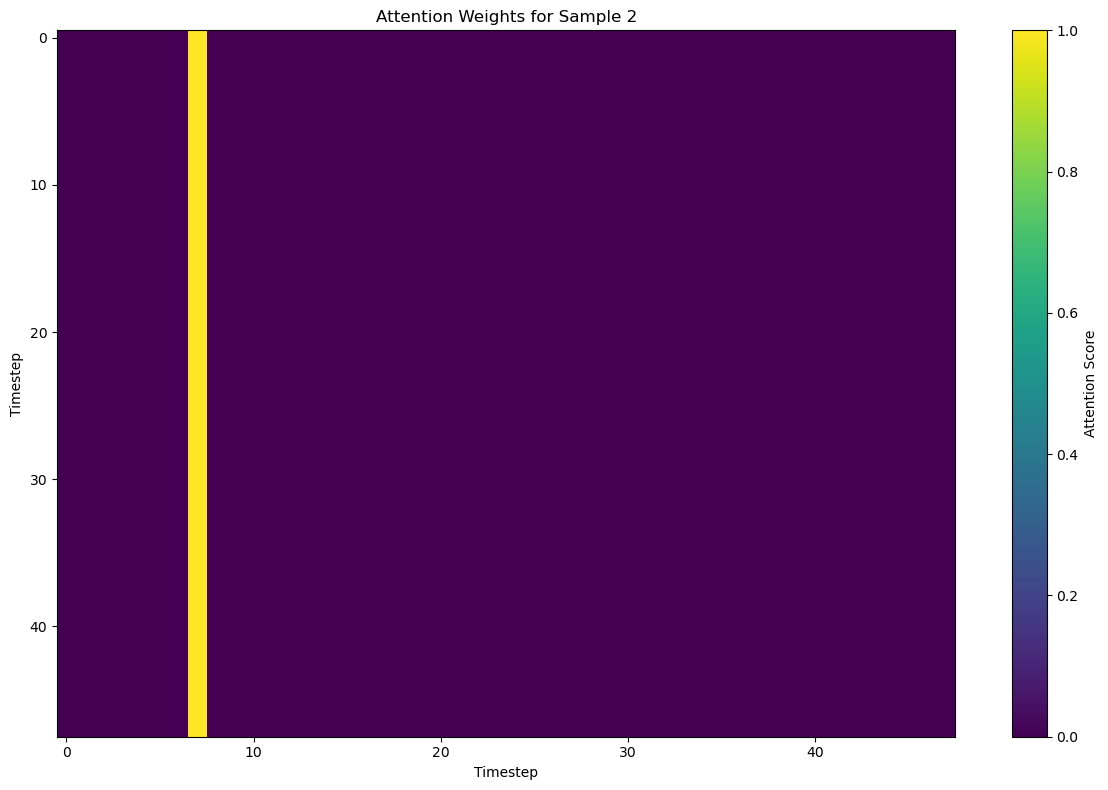

Sample 3 attention weights shape: (48, 48)


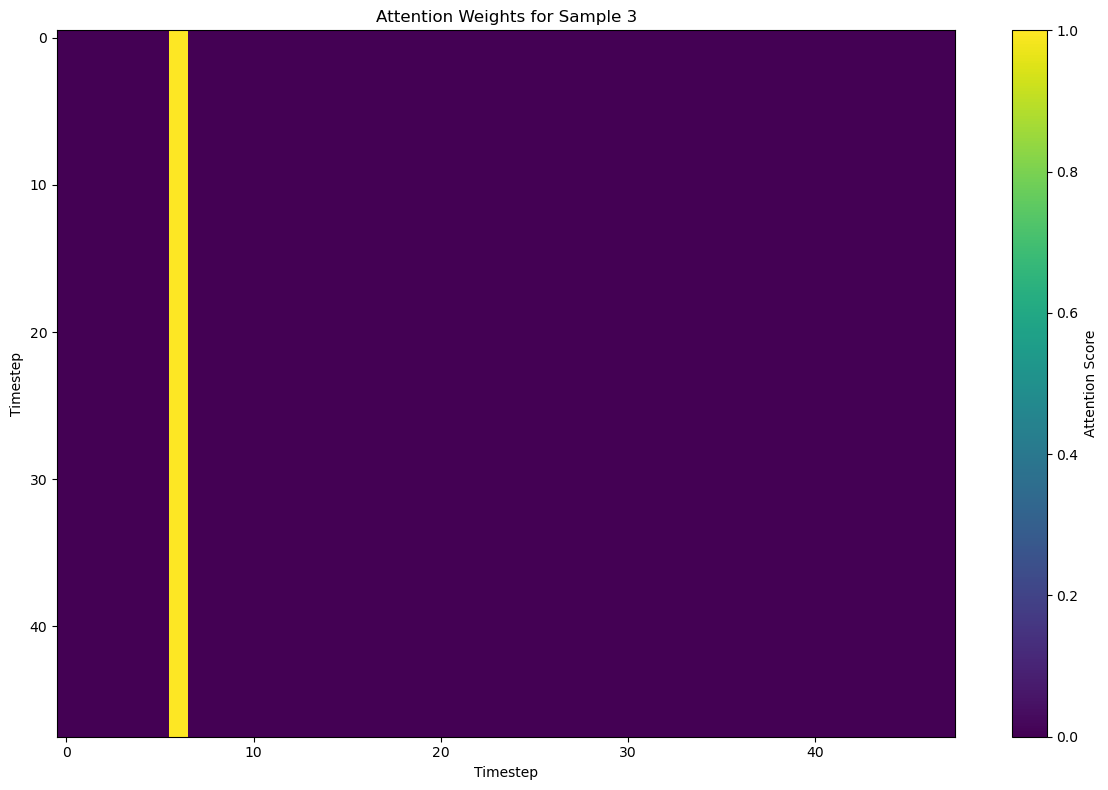

Sample 4 attention weights shape: (48, 48)


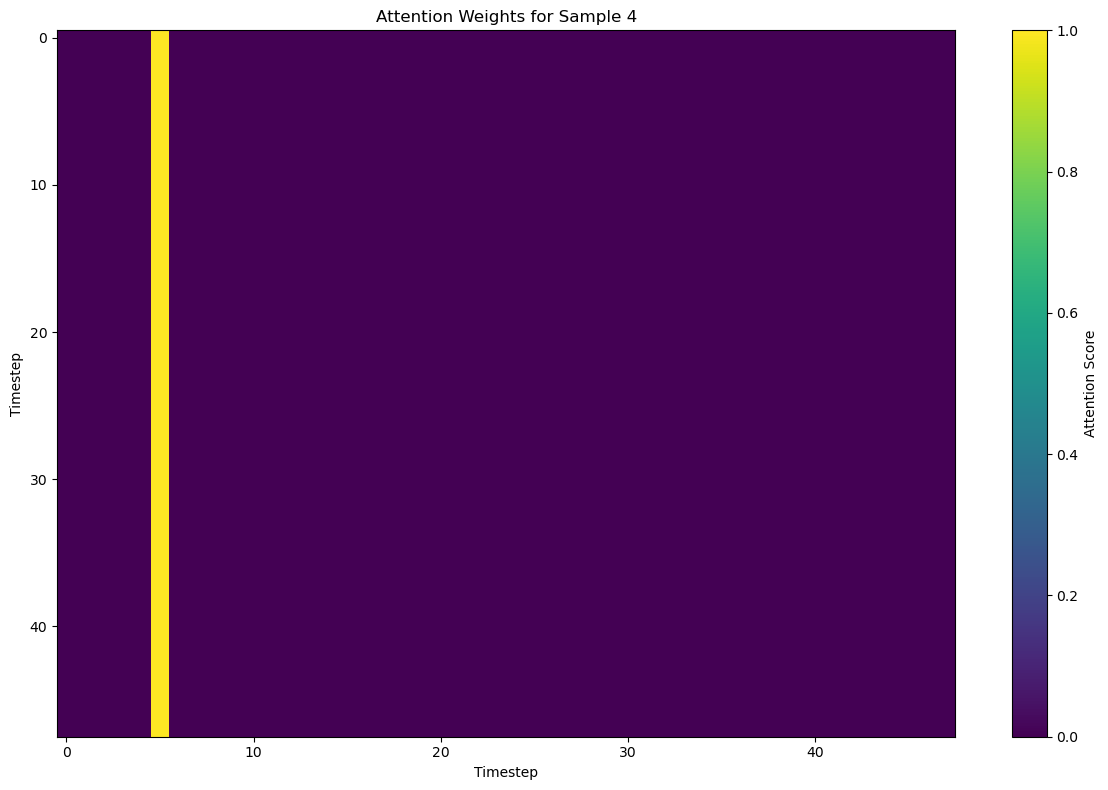

Sample 5 attention weights shape: (48, 48)


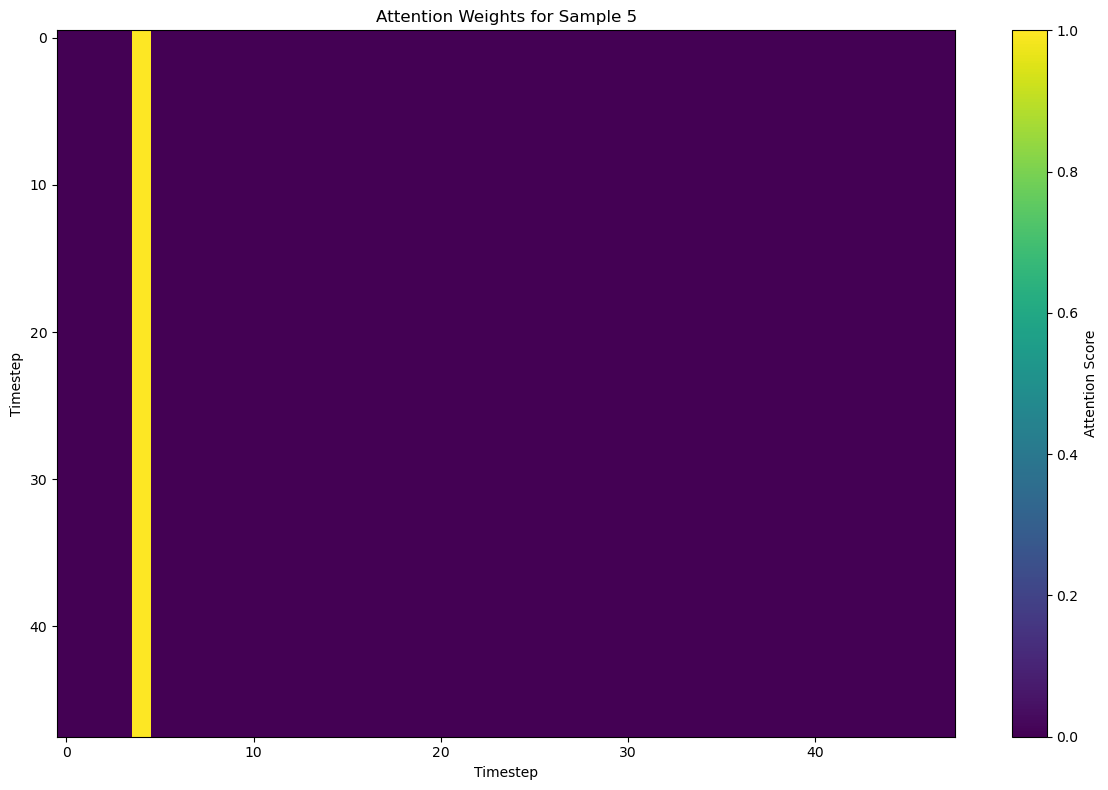

In [126]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Dropout, Layer
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt

# Custom Scaled Dot-Product Attention Layer
class ScaledDotProductAttention(Layer):
    def __init__(self, **kwargs):
        super(ScaledDotProductAttention, self).__init__(**kwargs)

    def call(self, query, key, value):
        d_k = tf.cast(tf.shape(query)[-1], tf.float32)
        scores = tf.matmul(query, key, transpose_b=True) / tf.sqrt(d_k)  # Scale scores
        attention_weights = tf.nn.softmax(scores, axis=-1)  # Softmax over last axis
        output = tf.matmul(attention_weights, value)
        return output, attention_weights

# Temporal Fusion Transformer Layer
class TemporalFusionTransformer(Layer):
    def __init__(self, feature_dim, num_heads=4, dropout_rate=0.1, **kwargs):
        super(TemporalFusionTransformer, self).__init__(**kwargs)
        self.feature_dim = feature_dim
        self.num_heads = num_heads
        self.dropout_rate = dropout_rate
        self.query_dense = Dense(feature_dim)
        self.key_dense = Dense(feature_dim)
        self.value_dense = Dense(feature_dim)
        self.attention = ScaledDotProductAttention()
        self.dropout = Dropout(dropout_rate)
        self.layer_norm = tf.keras.layers.LayerNormalization()

    def call(self, inputs):
        # Query, Key, Value projections
        query = self.query_dense(inputs)  # (batch_size, timesteps, feature_dim)
        key = self.key_dense(inputs)
        value = self.value_dense(inputs)

        # Scaled dot-product attention
        attention_output, attention_weights = self.attention(query, key, value)

        # Dropout and residual connection
        attention_output = self.dropout(attention_output)
        attention_output += inputs  # Residual connection

        # Layer normalization
        output = self.layer_norm(attention_output)

        return output, attention_weights

# Build the TFT Model
def build_tft_model(timesteps, feature_dim, num_heads=4, dropout_rate=0.1):
    inputs = Input(shape=(timesteps, feature_dim))  # Input shape: (48, 11)

    # Temporal Fusion Transformer Layer
    tft_layer = TemporalFusionTransformer(feature_dim, num_heads=num_heads, dropout_rate=dropout_rate)
    tft_output, attention_weights = tft_layer(inputs)

    # Fully Connected Layers
    x = Dense(64, activation='relu')(tft_output)
    x = Dropout(dropout_rate)(x)
    predictions = Dense(1)(x)  # Predict the next timestep

    # Model for training (only predictions)
    model = Model(inputs, predictions)

    # Model for inference (predictions + attention weights)
    inference_model = Model(inputs, [predictions, attention_weights])

    return model, inference_model

# Use the dataset shapes directly
timesteps = X_train.shape[1]  # Number of timesteps (48)
feature_dim = X_train.shape[2]  # Number of features (11)

# Build and Compile the TFT Model
tft_model, tft_inference_model = build_tft_model(timesteps=timesteps, feature_dim=feature_dim)

tft_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train the model
history = tft_model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, batch_size=32)

# Evaluate the model
test_loss, test_mae = tft_model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}, Test MAE: {test_mae}")

# Predict and extract attention weights using the inference model
predictions, attention_weights = tft_inference_model.predict(X_test[:5])  # First 5 samples from test set

# Visualize Attention Weights
for i, sample_weights in enumerate(attention_weights):
    print(f"Sample {i+1} attention weights shape: {sample_weights.shape}")  # Debug the shape

    plt.figure(figsize=(12, 8))
    plt.title(f"Attention Weights for Sample {i+1}")
    plt.imshow(sample_weights, aspect='auto', cmap='viridis')
    plt.colorbar(label='Attention Score')
    plt.xlabel('Timestep')
    plt.ylabel('Timestep')
    plt.tight_layout()
    plt.show()


Attention weights shape: (None, 48, 11)
Attention output shape: (None, 48, 11)
Attention weights shape: (None, 48, 11)
Attention output shape: (None, 48, 11)
Epoch 1/10
Attention weights shape: (None, 48, 11)
Attention output shape: (None, 48, 11)
Attention weights shape: (None, 48, 11)
Attention output shape: (None, 48, 11)
426/426 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 43384.6094 - mae: 131.5618Attention weights shape: (None, 48, 11)
Attention output shape: (None, 48, 11)
426/426 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 43330.7773 - mae: 131.4470 - val_loss: 3694.8521 - val_mae: 53.9963
Epoch 2/10
426/426 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 12134.8799 - mae: 63.6269 - val_loss: 4055.0100 - val_mae: 56.4280
Epoch 3/10
426/426 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 11872.0693 - mae: 63.6251 - val_loss: 4695.8276 - val_mae: 60.4142
Epoch 4/10
426/426 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 11555.4570 - mae: 63.4233 - val_loss: 3508.8650 - val_mae: 52.6532
Epoch 5/10
426/426 ━━

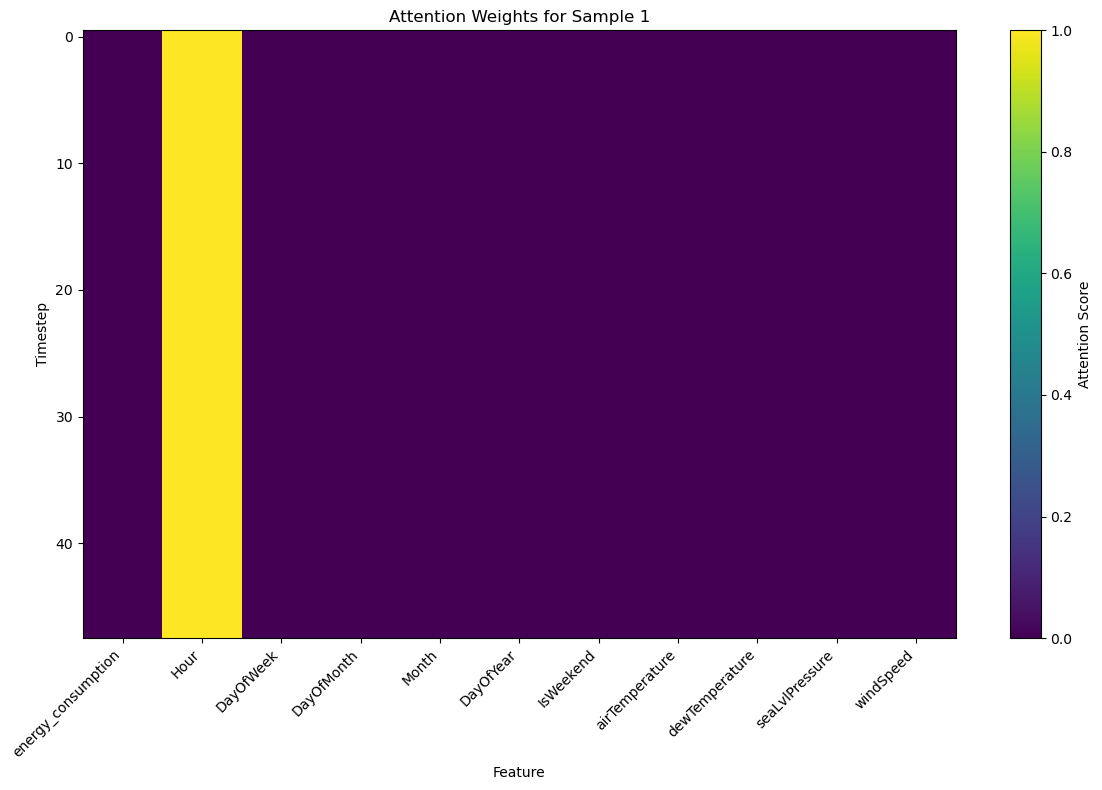

Sample 2 attention weights shape: (48, 11)


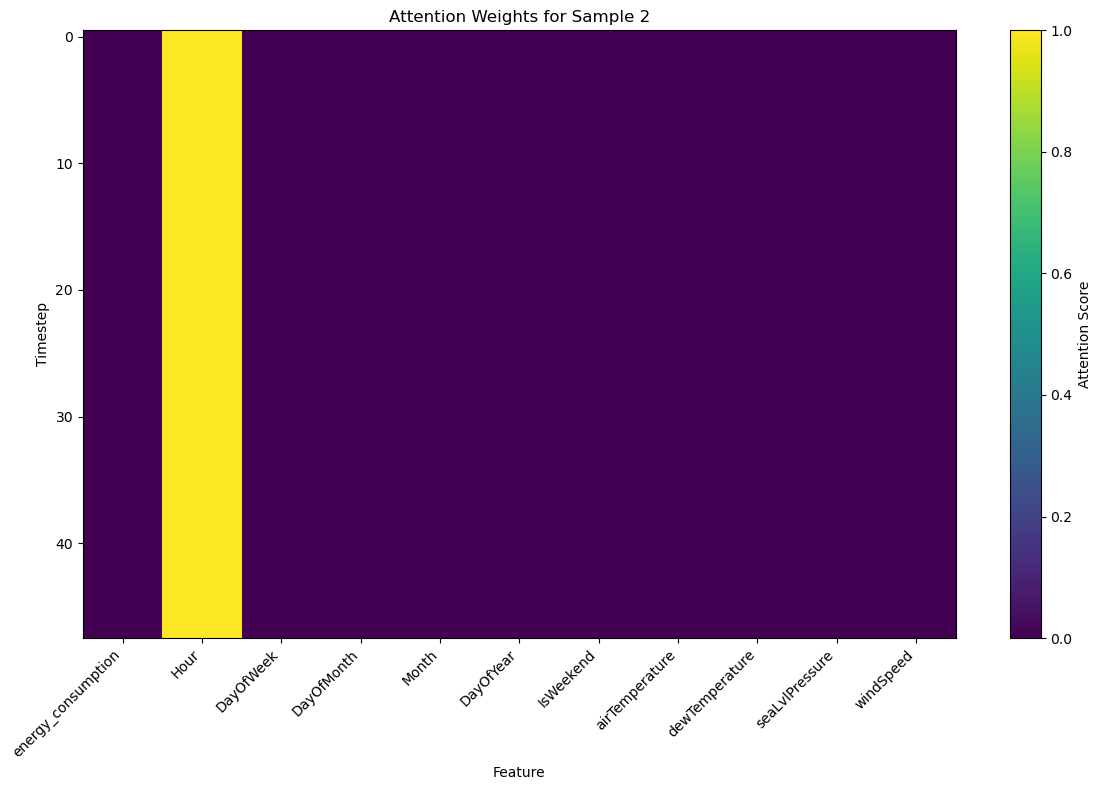

Sample 3 attention weights shape: (48, 11)


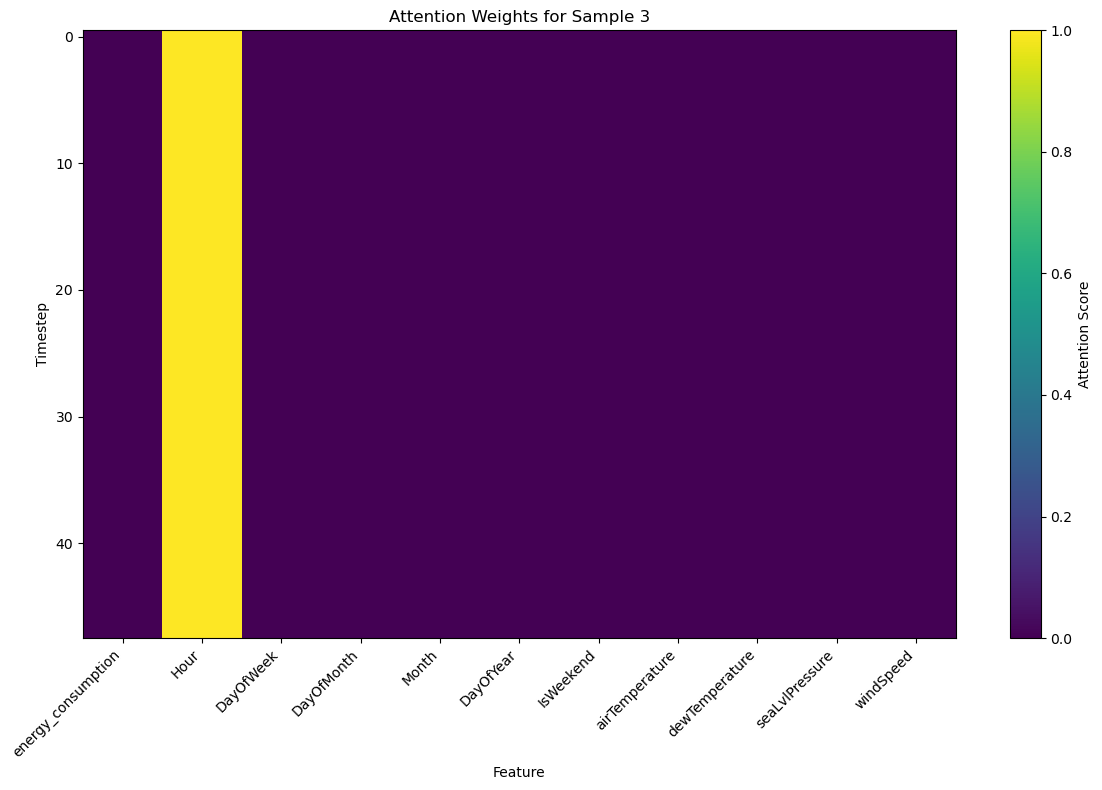

Sample 4 attention weights shape: (48, 11)


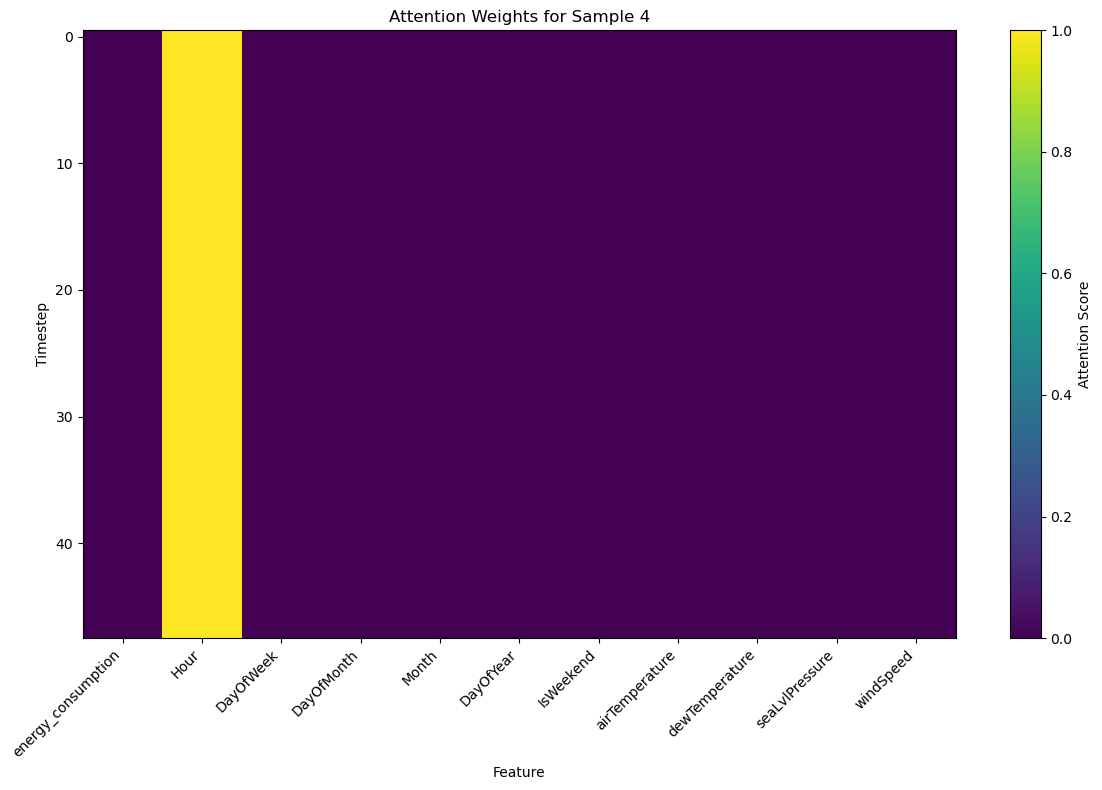

Sample 5 attention weights shape: (48, 11)


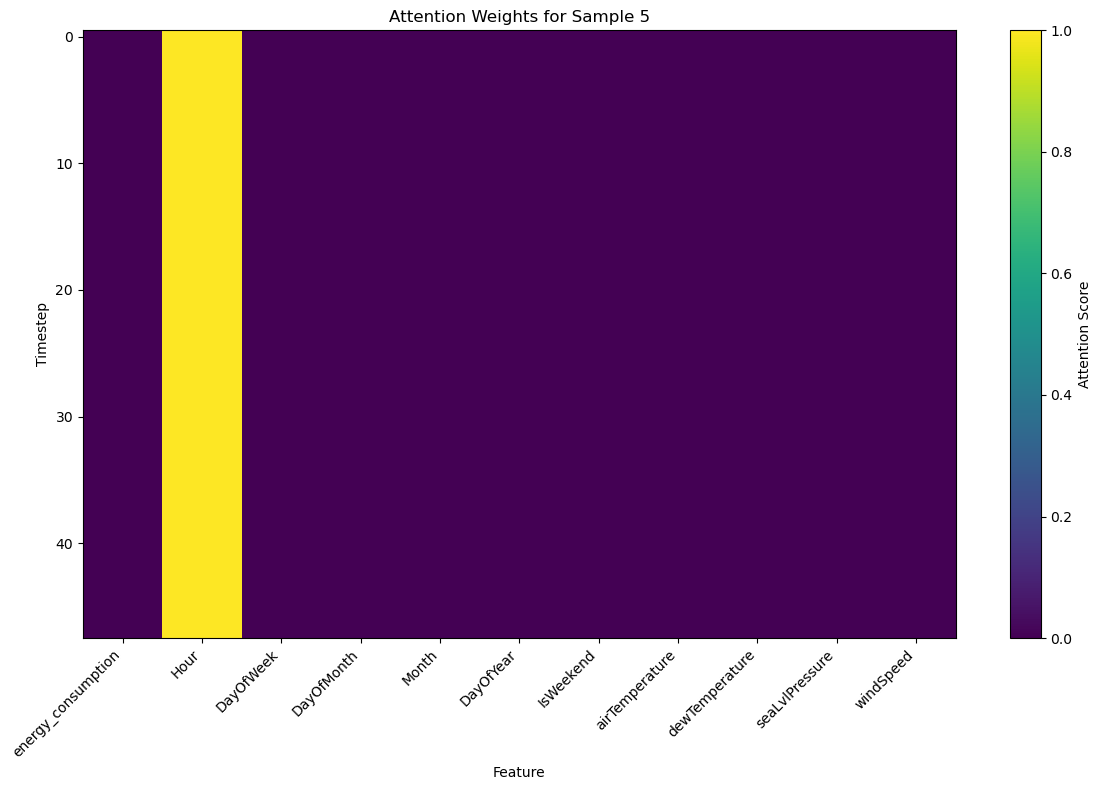

In [116]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Conv1D, LayerNormalization, Dropout, Lambda
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Layer, Softmax
import matplotlib.pyplot as plt

# TCN Block
def tcn_block(inputs, filters, kernel_size, dilation_rate, dropout_rate):
    x = Conv1D(filters, kernel_size, dilation_rate=dilation_rate, padding='causal', activation='relu')(inputs)
    x = LayerNormalization()(x)
    x = Dropout(dropout_rate)(x)
    return x


class FeatureAttention(Layer):
    def __init__(self, feature_dim, **kwargs):
        super(FeatureAttention, self).__init__(**kwargs)
        self.feature_dim = feature_dim
        self.query_dense = Dense(feature_dim, kernel_initializer="he_normal")
        self.key_dense = Dense(feature_dim, kernel_initializer="he_normal")
        self.value_dense = Dense(feature_dim, kernel_initializer="he_normal")
        self.softmax = Softmax(axis=-1)  # Normalize across features

    def call(self, inputs):
        # Query, Key, Value projections
        query = self.query_dense(inputs)  # (batch_size, timesteps, feature_dim)
        key = self.key_dense(inputs)      # (batch_size, timesteps, feature_dim)
        value = self.value_dense(inputs)  # (batch_size, timesteps, feature_dim)

        # Compute raw attention scores across features (element-wise product)
        scores = query * key  # Element-wise multiplication (batch_size, timesteps, feature_dim)

        # Normalize scores across the feature dimension
        attention_weights = self.softmax(scores)  # Normalize across features (batch_size, timesteps, feature_dim)

        # Apply attention weights to the value tensor
        attention_output = attention_weights * value  # Element-wise multiplication (batch_size, timesteps, feature_dim)

        # Debugging shapes
        print(f"Attention weights shape: {attention_weights.shape}")  # Should be (batch_size, timesteps, feature_dim)
        print(f"Attention output shape: {attention_output.shape}")    # Should be (batch_size, timesteps, feature_dim)

        return attention_weights, attention_output



# Build TCN Model with Attention
def build_tcn_model(timesteps, feature_dim, filters=64, kernel_size=3, num_tcn_blocks=3, dropout_rate=0.2):
    inputs = Input(shape=(timesteps, feature_dim))  # Input shape: (48, 11)
    
    # TCN Layers
    x = inputs
    for i in range(num_tcn_blocks):
        x = tcn_block(x, filters=filters, kernel_size=kernel_size, dilation_rate=2**i, dropout_rate=dropout_rate)
    
    # Project TCN output back to feature_dim for compatibility with FeatureAttention
    x = Dense(feature_dim)(x)
    
    # Feature Attention Layer
    attention_layer = FeatureAttention(feature_dim=feature_dim)
    attention_weights, attention_output = attention_layer(x)
    
    # Global Pooling + Fully Connected Layer
    x = Lambda(lambda x: tf.reduce_sum(x, axis=1))(attention_output)  # Aggregate across timesteps
    x = Dense(64, activation='relu')(x)
    outputs = Dense(1)(x)  # Predict the next timestep
    
    model = Model(inputs, outputs)
    return model, attention_layer




# Dataset Initialization
# Assume X_train, y_train, X_val, y_val, X_test, y_test are already loaded and have correct dimensions.
timesteps = X_train.shape[1]  # Number of timesteps (48)
feature_dim = X_train.shape[2]  # Number of features (11)

# Build the model
tcn_model, attention_layer = build_tcn_model(timesteps=timesteps, feature_dim=feature_dim)

# Compile and train the model
tcn_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
history = tcn_model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, batch_size=32)

# Evaluate the model
test_loss, test_mae = tcn_model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}, Test MAE: {test_mae}")

# Sub-model for extracting attention weights
attention_extractor = Model(
    inputs=tcn_model.input,
    outputs=attention_layer.output[0]  # Access the attention weights output
)

# Extract attention weights for visualization
X_sample = X_test[:5]  # Take a small batch for visualization
attention_weights = attention_extractor.predict(X_sample)


# List of feature names
feature_names = df_scaled.columns

# Visualize Attention Weights
for i, sample_weights in enumerate(attention_weights):
    print(f"Sample {i+1} attention weights shape: {sample_weights.shape}")  # Should be (48, 11)

    plt.figure(figsize=(12, 8))  # Adjust figure size for better readability
    plt.title(f"Attention Weights for Sample {i+1}")
    plt.imshow(sample_weights.squeeze(), aspect='auto', cmap='viridis')
    plt.colorbar(label='Attention Score')
    plt.xticks(ticks=range(len(feature_names)), labels=feature_names, rotation=45, ha='right')  # Add feature names to x-axis
    plt.xlabel('Feature')
    plt.ylabel('Timestep')
    plt.tight_layout()  # Adjust layout to avoid overlap
    plt.show()




In [114]:
pd.DataFrame(data= sample_weights)

,0,1,2,3,4,5,6,7,8,9,...,38,39,40,41,42,43,44,45,46,47
0,0.000076,0.000053,0.000057,0.000082,0.000063,0.000052,0.000037,0.000187,0.000021,0.000035,...,0.024143,0.019935,0.015916,0.017051,0.022516,0.025483,0.026538,0.029566,0.020492,0.019822
1,0.000048,0.000032,0.000035,0.000053,0.000037,0.000030,0.000023,0.000132,0.000015,0.000024,...,0.023536,0.019209,0.015124,0.016270,0.022134,0.025983,0.027821,0.029590,0.019889,0.019191
2,0.000008,0.000004,0.000005,0.000008,0.000009,0.000006,0.000004,0.000038,0.000005,0.000007,...,0.024721,0.021586,0.015788,0.016346,0.022485,0.024256,0.021486,0.026916,0.018600,0.017643
3,0.000057,0.000039,0.000044,0.000066,0.000045,0.000038,0.000028,0.000153,0.000018,0.000031,...,0.023197,0.018668,0.014774,0.016034,0.022066,0.026341,0.028792,0.030043,0.019892,0.019204
4,0.000015,0.000009,0.000011,0.000019,0.000018,0.000012,0.000008,0.000068,0.000015,0.000018,...,0.024366,0.021517,0.015878,0.016484,0.023023,0.026502,0.025587,0.027019,0.018727,0.017733
5,0.000017,0.000011,0.000014,0.000023,0.000023,0.000016,0.000010,0.000076,0.000014,0.000018,...,0.024092,0.020747,0.015279,0.016025,0.022580,0.025854,0.025011,0.027517,0.018601,0.017636
6,0.000086,0.000057,0.000056,0.000099,0.000057,0.000050,0.000019,0.000100,0.000010,0.000019,...,0.022143,0.017819,0.013626,0.014846,0.022248,0.028921,0.033644,0.029874,0.018756,0.017894
7,0.000246,0.000169,0.000152,0.000251,0.000111,0.000110,0.000054,0.000212,0.000022,0.000046,...,0.021539,0.017081,0.014057,0.015510,0.022313,0.029800,0.037215,0.030796,0.019957,0.019313
8,0.000661,0.000542,0.000469,0.001050,0.000513,0.000455,0.000150,0.000548,0.000122,0.000198,...,0.019995,0.016613,0.013366,0.014496,0.021293,0.031513,0.046421,0.027070,0.017933,0.017178
9,0.000396,0.000314,0.000288,0.000593,0.000314,0.000274,0.000108,0.000427,0.000085,0.000138,...,0.020786,0.017184,0.013819,0.014987,0.021742,0.030830,0.042520,0.027876,0.018519,0.017763


In [53]:
# tcn_model, tcn_metrics, history_tcn = my.implement_tcn(X_train, y_train, X_val, y_val, X_test, y_test, 
#                                                        learning_rate=5e-8, epochs=50, batch_size=64)

# print("TCN Metrics:", tcn_metrics)

In [54]:
# tcn_with_attention_model, tcn_with_attention_metrics, attention_scores, history_tcn_with_attention = my.implement_tcn_with_attention(
#     X_train, y_train, X_val, y_val, X_test, y_test,
#     learning_rate=5e-5, epochs=50, batch_size=64)

# print("TCN Metrics:", tcn_with_attention_metrics)

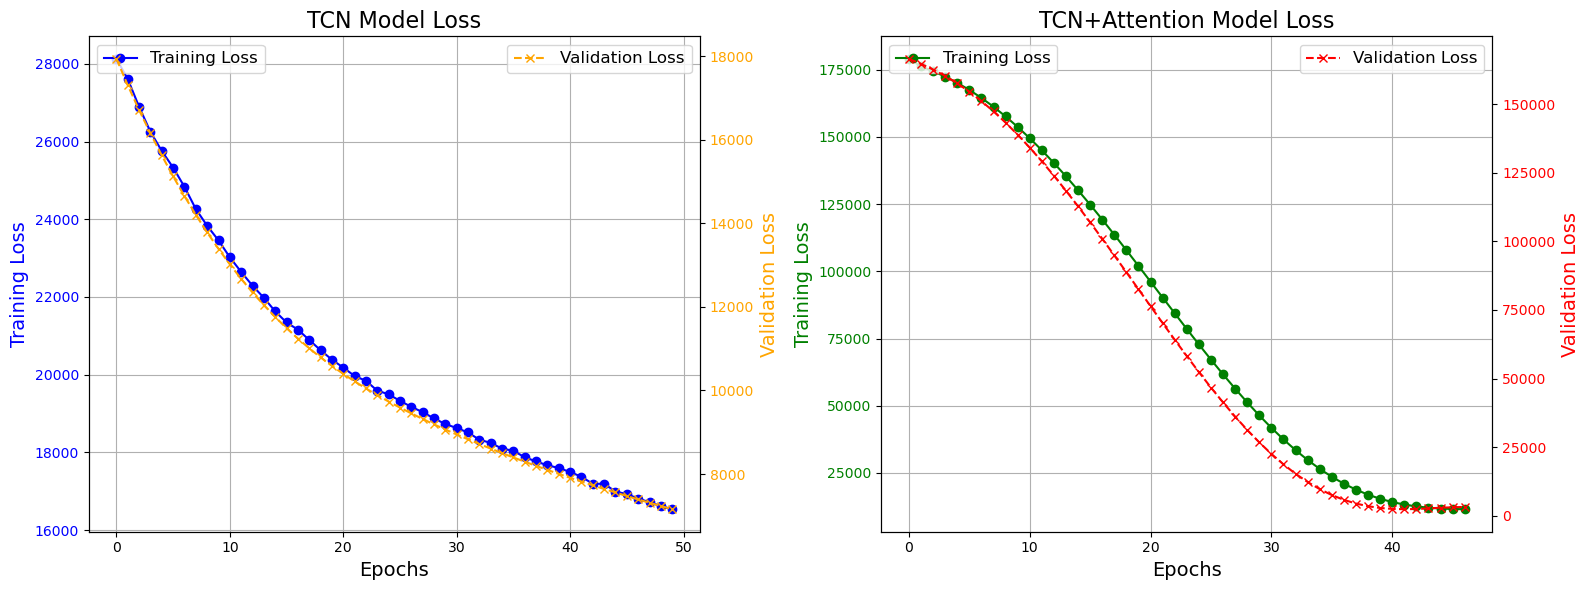

In [6]:
import matplotlib.pyplot as plt

def plot_loss_curves_separately(history_tcn, history_tcn_with_attention):
    # Extract loss and validation loss for TCN
    tcn_loss = history_tcn.history['loss']
    tcn_val_loss = history_tcn.history['val_loss']

    # Extract loss and validation loss for TCN+Attention
    tcn_with_attention_loss = history_tcn_with_attention.history['loss']
    tcn_with_attention_val_loss = history_tcn_with_attention.history['val_loss']

    # Create a figure with 1 row and 2 columns
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # TCN Model Loss
    ax1 = axes[0]
    ax2 = ax1.twinx()  # Create a twin Y-axis for the second scale
    ax1.plot(tcn_loss, label='Training Loss', linestyle='-', marker='o', color='blue')
    ax2.plot(tcn_val_loss, label='Validation Loss', linestyle='--', marker='x', color='orange')

    ax1.set_title('TCN Model Loss', fontsize=16)
    ax1.set_xlabel('Epochs', fontsize=14)
    ax1.set_ylabel('Training Loss', fontsize=14, color='blue')
    ax2.set_ylabel('Validation Loss', fontsize=14, color='orange')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax2.tick_params(axis='y', labelcolor='orange')
    ax1.grid(True)
    ax1.legend(['Training Loss'], loc='upper left', fontsize=12)
    ax2.legend(['Validation Loss'], loc='upper right', fontsize=12)

    # TCN+Attention Model Loss
    ax3 = axes[1]
    ax4 = ax3.twinx()  # Create a twin Y-axis for the second scale
    ax3.plot(tcn_with_attention_loss, label='Training Loss', linestyle='-', marker='o', color='green')
    ax4.plot(tcn_with_attention_val_loss, label='Validation Loss', linestyle='--', marker='x', color='red')

    ax3.set_title('TCN+Attention Model Loss', fontsize=16)
    ax3.set_xlabel('Epochs', fontsize=14)
    ax3.set_ylabel('Training Loss', fontsize=14, color='green')
    ax4.set_ylabel('Validation Loss', fontsize=14, color='red')
    ax3.tick_params(axis='y', labelcolor='green')
    ax4.tick_params(axis='y', labelcolor='red')
    ax3.grid(True)
    ax3.legend(['Training Loss'], loc='upper left', fontsize=12)
    ax4.legend(['Validation Loss'], loc='upper right', fontsize=12)

    # Adjust layout and show the plot
    plt.tight_layout()
    plt.show()


plot_loss_curves_separately(history_tcn, history_tcn_with_attention)

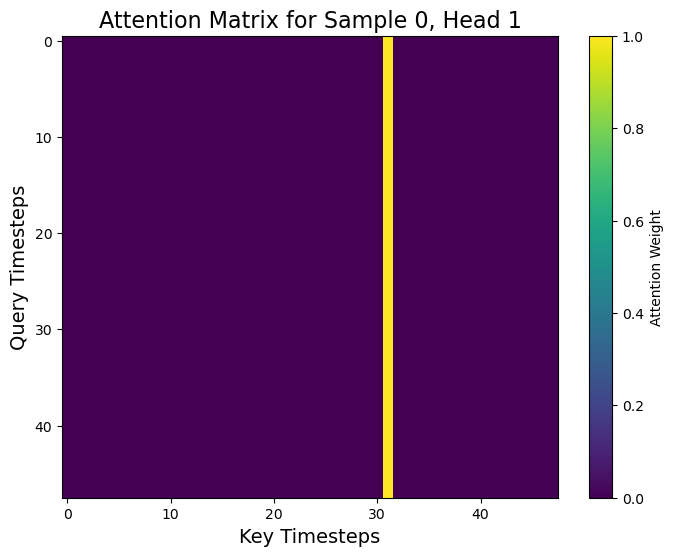

In [17]:
import matplotlib.pyplot as plt
import numpy as np

def plot_attention(attention_scores, sample_index=0, head_index=0):
    """
    Visualize the attention weights for a specific sample and attention head.

    Parameters:
        attention_scores (numpy.ndarray): Attention weights of shape (batch_size, num_heads, seq_len, seq_len).
        sample_index (int): Index of the sample to visualize.
        head_index (int): Index of the attention head to visualize.
    """
    # Extract the attention weights for the specified sample and head
    attention_matrix = attention_scores[sample_index, head_index]

    # Plot the attention matrix
    plt.figure(figsize=(8, 6))
    plt.imshow(attention_matrix, cmap='viridis', aspect='auto')
    plt.colorbar(label='Attention Weight')
    plt.title(f'Attention Matrix for Sample {sample_index}, Head {head_index}', fontsize=16)
    plt.xlabel('Key Timesteps', fontsize=14)
    plt.ylabel('Query Timesteps', fontsize=14)
    plt.show()

# Example usage
# Assuming `attention_scores` is a numpy array of shape (1699, 2, 48, 48)
# Convert to numpy if needed: attention_scores = np.array(attention_scores)
plot_attention(attention_scores, sample_index=0, head_index=1)


In [19]:
attention_scores[0,0,:,:]

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)